In [1]:
import os
os.environ['MUJOCO_GL'] = 'egl'

In [5]:
# 역진자 테스트
xml = """
<mujoco model="inverted pendulum">
    <compiler inertiafromgeom="true"/>
    <default>
        <joint armature="0" damping="1" limited="true"/>
        <geom friction="1 0.1 0.1" rgba="0.7 0.7 0 1"/>
        <tendon />
        <motor ctrlrange="-3 3"/>
    </default>
    <option gravity="0 0 -9.81" integrator="Euler" timestep="0.01"/>
    <size nstack="3000"/>
    <worldbody>
        <geom name="rail" pos="0 0 0" quat="0.707 0 0.707 0" rgba="0.3 0.3 0.7 1" size="0.02 1" type="capsule" contype="0" conaffinity="0"/>
        <body name="cart" pos="0 0 0">
            <joint axis="1 0 0" limited="true" name="slider" pos="0 0 0" range="-1.2 1.2" type="slide"/>
            <geom name="cart" pos="0 0 0" quat="0.707 0 0.707 0" size="0.1 0.1" type="capsule" />
            <body name="pole" pos="0 0 0">
                <joint axis="0 1 0" name="hinge" pos="0 0 0" type="hinge" limited="false"/>
                <geom fromto="0 0 0 0.001 0 0.6" name="cpole" rgba="0 0.7 0.7 1" size="0.049 0.3" type="capsule"/>
            </body>
        </body>
    </worldbody>
    <actuator>
        <motor ctrllimited="true" ctrlrange="-3 3" gear="10" joint="slider" name="slide"/>
    </actuator>
</mujoco>
"""

In [6]:
# 랜러더 구성
import mujoco

model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

In [7]:
# 시뮬레이션
duration = 5
framerate = 60
frames = []

data.qpos[0] = -0.5

while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

In [9]:
from IPython.display import Image, clear_output, display
import cv2

# 영상 출력
def display_image(frame):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    _, buffer = cv2.imencode('.jpg', frame)
    clear_output(wait=True)
    display(Image(data=buffer, width=500))

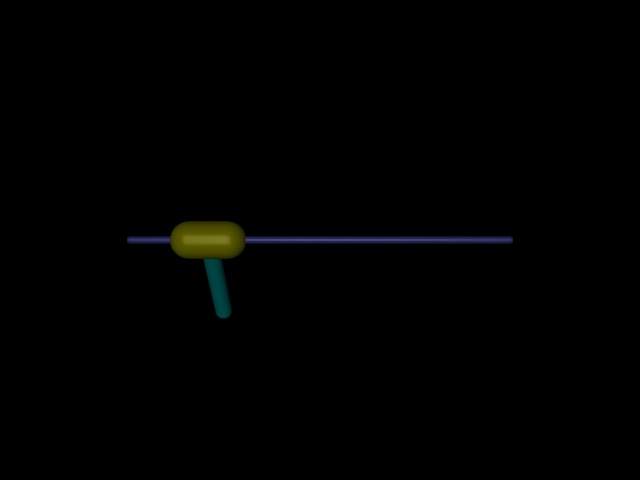

In [11]:
import time
for frame in frames:
    display_image(frame)
    time.sleep(1.0 / framerate)